Using sample weights (w_combo).

Classification Report (Test Set):
              precision    recall  f1-score   support

           0      0.491     0.484     0.487      3751
           1      0.491     0.498     0.494      3751

    accuracy                          0.491      7502
   macro avg      0.491     0.491     0.491      7502
weighted avg      0.491     0.491     0.491      7502

ROC-AUC: 0.490


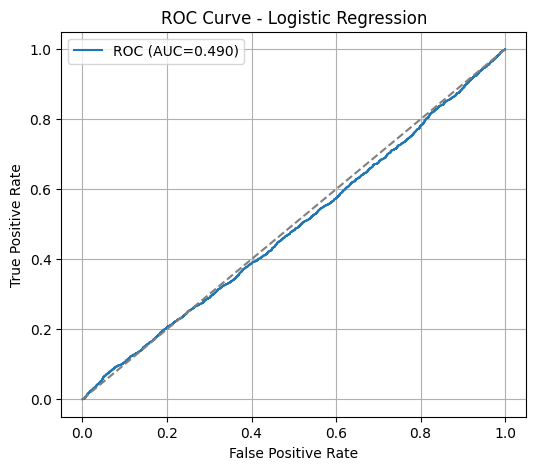


Top positive predictors:
                     Feature  Coefficient
8          Smoking_Habit_bin     0.019554
12              Severity_ord     0.016877
3    Physical_Activity_Hours     0.004744
4         Social_Media_Usage     0.003762
9    Alcohol_Consumption_ord     0.002912
5   Consultation_History_bin     0.001405
7          Smoking_Habit_ord     0.000960
15               Country_lbl     0.000046
2                 Work_Hours    -0.000071
1                Sleep_Hours    -0.000930

Top negative predictors:
                    Feature  Coefficient
7         Smoking_Habit_ord     0.000960
15              Country_lbl     0.000046
2                Work_Hours    -0.000071
1               Sleep_Hours    -0.000930
0                       Age    -0.001400
13         Stress_Level_ord    -0.002124
10  Alcohol_Consumption_bin    -0.008686
11         Diet_Quality_ord    -0.017162
14           Occupation_lbl    -0.018116
6      Medication_Usage_bin    -0.023881


In [ ]:
# ============================================
# Logistic Regression Baseline for Mental Health Prediction
# Compatible with Zenodo dataset + your preprocessing script
# ============================================

import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# --------------------------
# 1. Load cleaned dataset
# --------------------------
df = pd.read_csv("clean_numeric_model.csv")

# Remove irrelevant / constant columns
drop_cols = [
    "User_ID",
    "Age_isna", "Sleep_Hours_isna", "Work_Hours_isna",
    "Physical_Activity_Hours_isna", "Social_Media_Usage_isna","Mental_Health_Condition_lbl"
]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

# --------------------------
# 2. Split by existing splits file
# --------------------------
splits = pd.read_csv("splits_70_15_15_k5.csv")

y = df["Has_MH_condition_bin"]
X = df.drop(columns=["Has_MH_condition_bin"])

train_idx = splits.index[splits["split"] == "train"]
val_idx   = splits.index[splits["split"] == "val"]
test_idx  = splits.index[splits["split"] == "test"]

X_train, y_train = X.loc[train_idx], y.loc[train_idx]
X_val,   y_val   = X.loc[val_idx],   y.loc[val_idx]
X_test,  y_test  = X.loc[test_idx],  y.loc[test_idx]

# --------------------------
# 3. (Optional) Load sample weights
# --------------------------
try:
    weights = pd.read_csv("sample_weights.csv")
    w_train = weights.loc[train_idx, "w_combo"]
    use_weights = True
    print("Using sample weights (w_combo).")
except FileNotFoundError:
    w_train = None
    use_weights = False
    print("sample_weights.csv not found. Proceeding without weights.")

# --------------------------
# 4. Train Logistic Regression model
# --------------------------
model = LogisticRegression(
    solver="liblinear",     # robust for small/medium data
    penalty="l2",
    max_iter=1000,
    random_state=760
)

if use_weights:
    model.fit(X_train, y_train, sample_weight=w_train)
else:
    model.fit(X_train, y_train)

# --------------------------
# 5. Evaluate on test set
# --------------------------
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred, digits=3))
print("ROC-AUC: %.3f" % roc_auc_score(y_test, y_prob))

# --------------------------
# 6. Plot ROC Curve
# --------------------------
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC (AUC={roc_auc_score(y_test, y_prob):.3f})")
plt.plot([0,1],[0,1],"--",color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()

# --------------------------
# 7. Feature importance (coefficients)
# --------------------------
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

print("\nTop positive predictors:")
print(coef_df.head(10))
print("\nTop negative predictors:")
print(coef_df.tail(10))


In [1]:
# ============================================
# Stronger Logistic Regression Baseline
# - Standardization + Hyperparameter Tuning + Threshold Optimization
# - Uses existing splits and optional sample weights
# ============================================

import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve, precision_recall_curve,
    f1_score, confusion_matrix
)
import matplotlib.pyplot as plt

# --------------------------
# 1) Load data & basic cleanup (same as your baseline)
# --------------------------
df = pd.read_csv("clean_numeric_model.csv")

drop_cols = [
    "User_ID",
    "Age_isna", "Sleep_Hours_isna", "Work_Hours_isna",
    "Physical_Activity_Hours_isna", "Social_Media_Usage_isna","Mental_Health_Condition_lbl"
]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

splits = pd.read_csv("splits_70_15_15_k5.csv")

y = df["Has_MH_condition_bin"].astype(int)
X = df.drop(columns=["Has_MH_condition_bin"])

train_idx = splits.index[splits["split"] == "train"]
val_idx   = splits.index[splits["split"] == "val"]
test_idx  = splits.index[splits["split"] == "test"]

X_train, y_train = X.loc[train_idx], y.loc[train_idx]
X_val,   y_val   = X.loc[val_idx],   y.loc[val_idx]
X_test,  y_test  = X.loc[test_idx],  y.loc[test_idx]




Using sample weights (w_combo) for tuning & training.

Best params (CV on train): {'logreg__C': np.float64(0.01), 'logreg__class_weight': None, 'logreg__penalty': 'l1'}
Best mean CV AUC on train folds: 0.509
Best threshold (F1 on val): 0.050
Best threshold (Youden's J on val): 0.500

=== Test Set (with tuned threshold = 0.050) ===
              precision    recall  f1-score   support

           0      0.000     0.000     0.000      3751
           1      0.500     1.000     0.667      3751

    accuracy                          0.500      7502
   macro avg      0.250     0.500     0.333      7502
weighted avg      0.250     0.500     0.333      7502

ROC-AUC (probability-based): 0.488
Confusion Matrix (test):
 [[   0 3751]
 [   0 3751]]


/opt/anaconda3/envs/CS762/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/CS762/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/CS762/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

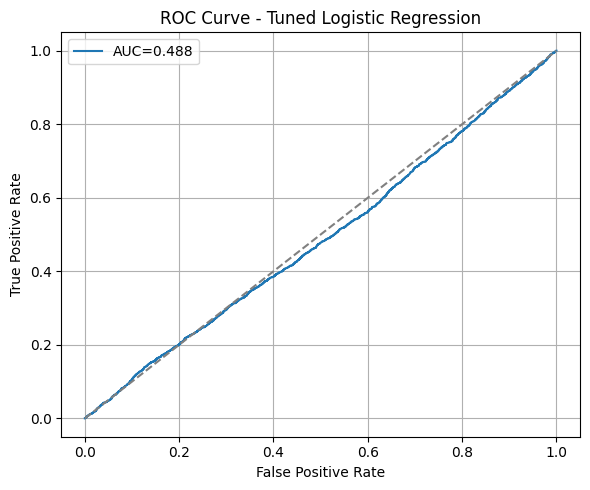

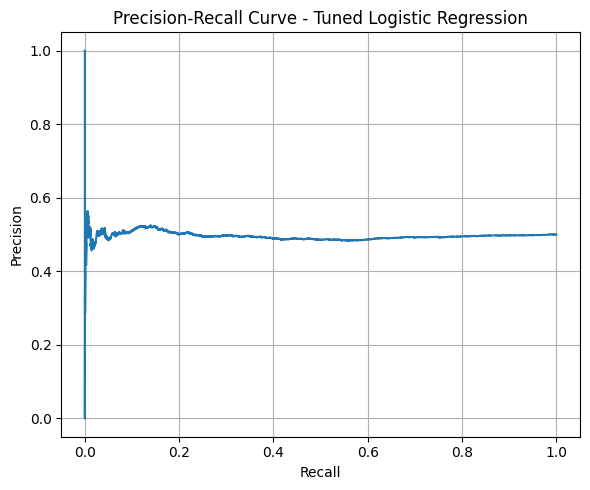


Top positive predictors (standardized):
                     Feature  Coefficient
3    Physical_Activity_Hours     0.003594
1                Sleep_Hours     0.000000
2                 Work_Hours     0.000000
4         Social_Media_Usage     0.000000
5   Consultation_History_bin     0.000000
7          Smoking_Habit_ord     0.000000
8          Smoking_Habit_bin     0.000000
9    Alcohol_Consumption_ord     0.000000
10   Alcohol_Consumption_bin     0.000000
12              Severity_ord     0.000000

Top negative predictors (standardized):
                    Feature  Coefficient
8         Smoking_Habit_bin     0.000000
9   Alcohol_Consumption_ord     0.000000
10  Alcohol_Consumption_bin     0.000000
12             Severity_ord     0.000000
13         Stress_Level_ord     0.000000
15              Country_lbl     0.000000
6      Medication_Usage_bin    -0.000595
11         Diet_Quality_ord    -0.002761
0                       Age    -0.008055
14           Occupation_lbl    -0.024815


In [8]:
# --------------------------
# 2) Optional sample weights (auto-detect)
# --------------------------
use_weights = False
w_train = None
try:
    weights = pd.read_csv("sample_weights.csv")
    # 与 train_idx 行对齐（你已确认两表对齐）
    w_train = weights.loc[train_idx, "w_combo"].values
    use_weights = True
    print("Using sample weights (w_combo) for tuning & training.")
except FileNotFoundError:
    print("sample_weights.csv not found. Proceeding without weights.")

# --------------------------
# 3) Pipeline: Standardize -> Logistic Regression (saga supports l1/l2)
# --------------------------
pipe = Pipeline([
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("logreg", LogisticRegression(
        solver="saga",       # 支持 l1/l2 且适合较高维
        penalty="l2",
        max_iter=5000,
        random_state=760,
        n_jobs=-1
    ))
])

# 超参数网格：C、正则范式、是否使用类权重平衡
param_grid = {
    "logreg__C": np.logspace(-3, 2, 6),     # 1e-3 ... 1e2
    "logreg__penalty": ["l1", "l2"],
    "logreg__class_weight": [None, "balanced"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=760)

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True,             # 用最佳参数在整个训练集上重训
    verbose=0
)

# 注意：将 sample_weight 传给最后一步模型（Pipeline 会把 sample_weight 传递给 logreg）


fit_kwargs = {}
if use_weights:
    fit_kwargs["logreg__sample_weight"] = w_train
grid.fit(X_train, y_train, **fit_kwargs)


print("\nBest params (CV on train):", grid.best_params_)
print("Best mean CV AUC on train folds: %.3f" % grid.best_score_)

best_model = grid.best_estimator_

# --------------------------
# 4) Threshold optimization on validation set
#    - try F1-maximizing threshold (also可切换到 Youden's J)
# --------------------------
y_val_prob = best_model.predict_proba(X_val)[:, 1]

# 4.1 F1-based threshold search
ths = np.linspace(0.05, 0.95, 181)
f1s = [f1_score(y_val, (y_val_prob > t).astype(int)) for t in ths]
best_t_f1 = ths[int(np.argmax(f1s))]

# 4.2 (可选) Youden's J: maximize TPR - FPR
fpr, tpr, thr_roc = roc_curve(y_val, y_val_prob)
youden_js = tpr - fpr
t_youden = thr_roc[int(np.argmax(youden_js))]

print("Best threshold (F1 on val): %.3f" % best_t_f1)
print("Best threshold (Youden's J on val): %.3f" % t_youden)

# 这里选 F1 阈值作为默认（若你更关注召回或特定代价，可换成 t_youden）
best_threshold = best_t_f1

# --------------------------
# 5) Final evaluation on test with the chosen threshold
# --------------------------
y_test_prob = best_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob > best_threshold).astype(int)

print("\n=== Test Set (with tuned threshold = %.3f) ===" % best_threshold)
print(classification_report(y_test, y_test_pred, digits=3))
print("ROC-AUC (probability-based): %.3f" % roc_auc_score(y_test, y_test_prob))

# 混淆矩阵
cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix (test):\n", cm)

# --------------------------
# 6) (Optional) Curves for record
# --------------------------
# ROC
fpr_t, tpr_t, _ = roc_curve(y_test, y_test_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr_t, tpr_t, label=f"AUC={roc_auc_score(y_test, y_test_prob):.3f}")
plt.plot([0,1],[0,1],"--",color="gray")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Logistic Regression")
plt.legend(); plt.grid(True); plt.tight_layout()
# plt.savefig("roc_lr_tuned.png", dpi=180)

# PR
prec, rec, _ = precision_recall_curve(y_test, y_test_prob)
plt.figure(figsize=(6,5))
plt.plot(rec, prec)
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Tuned Logistic Regression")
plt.grid(True); plt.tight_layout()
# plt.savefig("pr_lr_tuned.png", dpi=180)

plt.show()

# --------------------------
# 7) Coefficients (standardized)
# --------------------------
# 从 best_model 中取出归一化后的系数（注意：系数对应标准化后的特征）
final_lr = best_model.named_steps["logreg"]
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": final_lr.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

print("\nTop positive predictors (standardized):")
print(coef_df.head(10))
print("\nTop negative predictors (standardized):")
print(coef_df.tail(10))

In [3]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve, precision_recall_curve,
    f1_score, confusion_matrix
)
import matplotlib.pyplot as plt
# --------------------------
# 2) Optional sample weights
# --------------------------
use_weights = False
w_train, w_val = None, None
try:
    weights = pd.read_csv("sample_weights.csv")
    w_train = weights.loc[train_idx, "w_combo"].values
    w_val   = weights.loc[val_idx, "w_combo"].values
    use_weights = True
    print("Using sample weights (w_combo).")
except FileNotFoundError:
    print("sample_weights.csv not found. Proceeding without weights.")

# --------------------------
# 3) LightGBM Datasets
# --------------------------
dtrain = lgb.Dataset(X_train, label=y_train, weight=(w_train if use_weights else None))
dval   = lgb.Dataset(X_val,   label=y_val,   weight=(w_val   if use_weights else None))

# --------------------------
# 4) Base params + small search space
#    (keep it small; expand if needed)
# --------------------------
base_params = {
    "objective": "binary",
    "metric": "auc",
    "verbosity": -1,
    "seed": 760,
    "num_threads": -1
}

search_space = {
    "learning_rate": [0.05, 0.1],
    "num_leaves": [31, 63],
    "min_data_in_leaf": [20, 50],
    "feature_fraction": [0.9],
    "bagging_fraction": [0.8],
    "bagging_freq": [5],
    "lambda_l2": [0.0, 1.0]
}

def param_combos(space):
    keys = list(space.keys())
    for values in product(*[space[k] for k in keys]):
        yield {k: v for k, v in zip(keys, values)}

# --------------------------
# 5) Train with early stopping (callbacks) over grid
# --------------------------
best_auc = -np.inf
best_params = None
best_bst = None

for p in param_combos(search_space):
    params = base_params.copy()
    params.update(p)
    print(f"\n>> Try params: {p}")

    bst = lgb.train(
        params=params,
        train_set=dtrain,
        num_boost_round=2000,
        valid_sets=[dtrain, dval],
        valid_names=["train", "val"],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50),      # <-- version-safe early stopping
            lgb.log_evaluation(period=100)
        ]
    )
    # Get best val AUC
    val_auc = bst.best_score.get("val", {}).get("auc", None)
    if val_auc is None:  # older versions may use "valid_1"
        val_auc = bst.best_score.get("valid_1", {}).get("auc", -np.inf)

    print(f"Val AUC (best_iter={bst.best_iteration}): {val_auc:.5f}")

    if val_auc > best_auc:
        best_auc = val_auc
        best_params = params
        best_bst = bst

print("\nBest params:", best_params)
print("Best Val AUC:", best_auc)
print("Best iteration:", best_bst.best_iteration)

# --------------------------
# 6) Threshold optimization on VAL
# --------------------------
y_val_prob = best_bst.predict(X_val, num_iteration=best_bst.best_iteration)

ths = np.linspace(0.05, 0.95, 181)
f1s = [f1_score(y_val, (y_val_prob > t).astype(int)) for t in ths]
best_t_f1 = ths[int(np.argmax(f1s))]

fpr, tpr, thr_roc = roc_curve(y_val, y_val_prob)
youden_js = tpr - fpr
t_youden = thr_roc[int(np.argmax(youden_js))]

print(f"Best threshold (F1 on val): {best_t_f1:.3f}")
print(f"Best threshold (Youden's J on val): {t_youden:.3f}")

best_threshold = best_t_f1  # choose your metric of interest

# --------------------------
# 7) Final Test Evaluation
# --------------------------
y_test_prob = best_bst.predict(X_test, num_iteration=best_bst.best_iteration)
y_test_pred = (y_test_prob > best_threshold).astype(int)

print(f"\n=== Test Set (LightGBM, threshold={best_threshold:.3f}) ===")
print(classification_report(y_test, y_test_pred, digits=3))
print("ROC-AUC:", f"{roc_auc_score(y_test, y_test_prob):.3f}")

cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix (test):\n", cm)

# --------------------------
# 8) Curves
# --------------------------
# ROC
fpr_t, tpr_t, _ = roc_curve(y_test, y_test_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr_t, tpr_t, label=f"AUC={roc_auc_score(y_test, y_test_prob):.3f}")
plt.plot([0,1],[0,1],"--",color="gray")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LightGBM")
plt.legend(); plt.grid(True); plt.tight_layout()

# PR
prec, rec, _ = precision_recall_curve(y_test, y_test_prob)
plt.figure(figsize=(6,5))
plt.plot(rec, prec)
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-Recall Curve - LightGBM")
plt.grid(True); plt.tight_layout()

plt.show()

# --------------------------
# 9) Feature importance
# --------------------------
imp = best_bst.feature_importance(importance_type="gain")
imp_df = pd.DataFrame({"Feature": X.columns, "Importance": imp}) \
         .sort_values(by="Importance", ascending=False)
print("\nTop features by importance (gain):")
print(imp_df.head(15))

Using sample weights (w_combo).


NameError: name 'product' is not defined

Using sample weights (w_combo).

>> Try params: {'learning_rate': 0.05, 'num_leaves': 31, 'min_data_in_leaf': 20, 'feature_fraction': 0.9, 'bagging_fraction': 0.8, 'bagging_freq': 5, 'lambda_l2': 0.0}
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[7]	train's auc: 0.564169	val's auc: 0.512032
Val AUC (best_iter=7): 0.51203

>> Try params: {'learning_rate': 0.05, 'num_leaves': 31, 'min_data_in_leaf': 20, 'feature_fraction': 0.9, 'bagging_fraction': 0.8, 'bagging_freq': 5, 'lambda_l2': 1.0}
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[15]	train's auc: 0.592034	val's auc: 0.516548
Val AUC (best_iter=15): 0.51655

>> Try params: {'learning_rate': 0.05, 'num_leaves': 31, 'min_data_in_leaf': 50, 'feature_fraction': 0.9, 'bagging_fraction': 0.8, 'bagging_freq': 5, 'lambda_l2': 0.0}
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[25]	train's auc:

/opt/anaconda3/envs/CS762/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/CS762/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/CS762/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

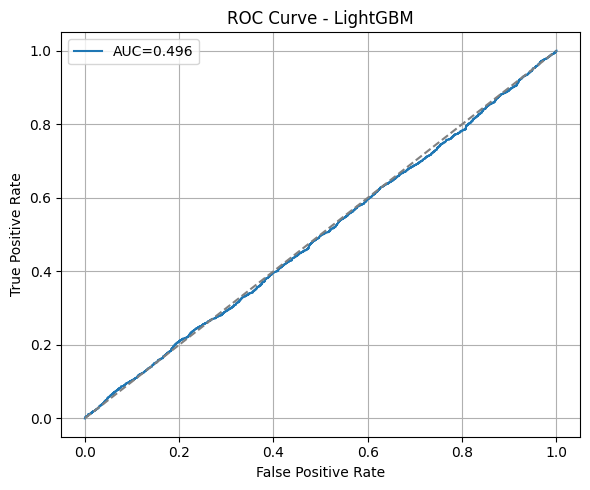

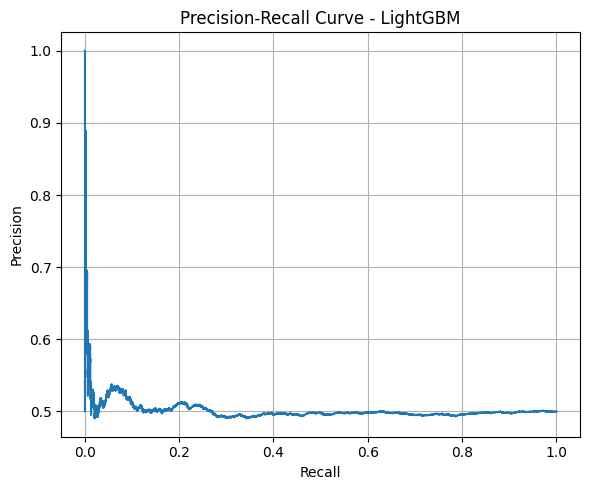


Top features by importance (gain):
                     Feature  Importance
1                Sleep_Hours  685.910430
4         Social_Media_Usage  655.728869
0                        Age  642.769121
2                 Work_Hours  457.009012
3    Physical_Activity_Hours  400.881531
15               Country_lbl  278.015579
14            Occupation_lbl  247.908499
11          Diet_Quality_ord  163.221881
9    Alcohol_Consumption_ord  152.958020
13          Stress_Level_ord  149.106808
7          Smoking_Habit_ord  123.807591
12              Severity_ord  115.846050
6       Medication_Usage_bin   86.744770
5   Consultation_History_bin   56.352980
8          Smoking_Habit_bin   14.490520


In [4]:
# ============================================
# LightGBM Clean Baseline (with callbacks early stopping)
# - sample_weight (train/val)
# - small manual grid search
# - threshold optimization on val, test evaluation
# ============================================

import pandas as pd
import numpy as np
import lightgbm as lgb
from itertools import product
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    precision_recall_curve, f1_score, confusion_matrix
)
import matplotlib.pyplot as plt

# --------------------------
# 1) Load & basic cleanup
# --------------------------
df = pd.read_csv("clean_numeric_model.csv")
drop_cols = [
    "User_ID",
    "Age_isna", "Sleep_Hours_isna", "Work_Hours_isna",
    "Physical_Activity_Hours_isna", "Social_Media_Usage_isna","Mental_Health_Condition_lbl"
]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

splits = pd.read_csv("splits_70_15_15_k5.csv")

y = df["Has_MH_condition_bin"].astype(int)
X = df.drop(columns=["Has_MH_condition_bin"])

train_idx = splits.index[splits["split"] == "train"]
val_idx   = splits.index[splits["split"] == "val"]
test_idx  = splits.index[splits["split"] == "test"]

X_train, y_train = X.loc[train_idx], y.loc[train_idx]
X_val,   y_val   = X.loc[val_idx],   y.loc[val_idx]
X_test,  y_test  = X.loc[test_idx],  y.loc[test_idx]

# --------------------------
# 2) Optional sample weights
# --------------------------
use_weights = False
w_train, w_val = None, None
try:
    weights = pd.read_csv("sample_weights.csv")
    w_train = weights.loc[train_idx, "w_combo"].values
    w_val   = weights.loc[val_idx, "w_combo"].values
    use_weights = True
    print("Using sample weights (w_combo).")
except FileNotFoundError:
    print("sample_weights.csv not found. Proceeding without weights.")

# --------------------------
# 3) LightGBM Datasets
# --------------------------
dtrain = lgb.Dataset(X_train, label=y_train, weight=(w_train if use_weights else None))
dval   = lgb.Dataset(X_val,   label=y_val,   weight=(w_val   if use_weights else None))

# --------------------------
# 4) Base params + small search space
#    (keep it small; expand if needed)
# --------------------------
base_params = {
    "objective": "binary",
    "metric": "auc",
    "verbosity": -1,
    "seed": 760,
    "num_threads": -1
}

search_space = {
    "learning_rate": [0.05, 0.1],
    "num_leaves": [31, 63],
    "min_data_in_leaf": [20, 50],
    "feature_fraction": [0.9],
    "bagging_fraction": [0.8],
    "bagging_freq": [5],
    "lambda_l2": [0.0, 1.0]
}

def param_combos(space):
    keys = list(space.keys())
    for values in product(*[space[k] for k in keys]):
        yield {k: v for k, v in zip(keys, values)}

# --------------------------
# 5) Train with early stopping (callbacks) over grid
# --------------------------
best_auc = -np.inf
best_params = None
best_bst = None

for p in param_combos(search_space):
    params = base_params.copy()
    params.update(p)
    print(f"\n>> Try params: {p}")

    bst = lgb.train(
        params=params,
        train_set=dtrain,
        num_boost_round=2000,
        valid_sets=[dtrain, dval],
        valid_names=["train", "val"],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50),      # <-- version-safe early stopping
            lgb.log_evaluation(period=100)
        ]
    )
    # Get best val AUC
    val_auc = bst.best_score.get("val", {}).get("auc", None)
    if val_auc is None:  # older versions may use "valid_1"
        val_auc = bst.best_score.get("valid_1", {}).get("auc", -np.inf)

    print(f"Val AUC (best_iter={bst.best_iteration}): {val_auc:.5f}")

    if val_auc > best_auc:
        best_auc = val_auc
        best_params = params
        best_bst = bst

print("\nBest params:", best_params)
print("Best Val AUC:", best_auc)
print("Best iteration:", best_bst.best_iteration)

# --------------------------
# 6) Threshold optimization on VAL
# --------------------------
y_val_prob = best_bst.predict(X_val, num_iteration=best_bst.best_iteration)

ths = np.linspace(0.05, 0.95, 181)
f1s = [f1_score(y_val, (y_val_prob > t).astype(int)) for t in ths]
best_t_f1 = ths[int(np.argmax(f1s))]

fpr, tpr, thr_roc = roc_curve(y_val, y_val_prob)
youden_js = tpr - fpr
t_youden = thr_roc[int(np.argmax(youden_js))]

print(f"Best threshold (F1 on val): {best_t_f1:.3f}")
print(f"Best threshold (Youden's J on val): {t_youden:.3f}")

best_threshold = best_t_f1  # choose your metric of interest

# --------------------------
# 7) Final Test Evaluation
# --------------------------
y_test_prob = best_bst.predict(X_test, num_iteration=best_bst.best_iteration)
y_test_pred = (y_test_prob > best_threshold).astype(int)

print(f"\n=== Test Set (LightGBM, threshold={best_threshold:.3f}) ===")
print(classification_report(y_test, y_test_pred, digits=3))
print("ROC-AUC:", f"{roc_auc_score(y_test, y_test_prob):.3f}")

cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix (test):\n", cm)

# --------------------------
# 8) Curves
# --------------------------
# ROC
fpr_t, tpr_t, _ = roc_curve(y_test, y_test_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr_t, tpr_t, label=f"AUC={roc_auc_score(y_test, y_test_prob):.3f}")
plt.plot([0,1],[0,1],"--",color="gray")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LightGBM")
plt.legend(); plt.grid(True); plt.tight_layout()

# PR
prec, rec, _ = precision_recall_curve(y_test, y_test_prob)
plt.figure(figsize=(6,5))
plt.plot(rec, prec)
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-Recall Curve - LightGBM")
plt.grid(True); plt.tight_layout()

plt.show()

# --------------------------
# 9) Feature importance
# --------------------------
imp = best_bst.feature_importance(importance_type="gain")
imp_df = pd.DataFrame({"Feature": X.columns, "Importance": imp}) \
         .sort_values(by="Importance", ascending=False)
print("\nTop features by importance (gain):")
print(imp_df.head(15))


=== Group Mean/Std by Target ===
                     Sleep_Hours           Work_Hours             \
                            mean       std       mean        std   
Has_MH_condition_bin                                               
0                       7.010731  1.726674  55.067272  14.679128   
1                       7.009137  1.738689  55.058447  14.704307   

                     Social_Media_Usage           Physical_Activity_Hours  \
                                   mean       std                    mean   
Has_MH_condition_bin                                                        
0                              3.243579  1.579143                4.963724   
1                              3.242741  1.591338                5.000360   

                                      Age             
                           std       mean        std  
Has_MH_condition_bin                                  
0                     3.166500  41.551534  13.859888  
1                   

/var/folders/_v/xh2vlxhx4ygf2lggz3xh55_40000gn/T/ipykernel_33959/4089331663.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target, y=feat, data=df, palette="Set2")
/var/folders/_v/xh2vlxhx4ygf2lggz3xh55_40000gn/T/ipykernel_33959/4089331663.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target, y=feat, data=df, palette="Set2")
/var/folders/_v/xh2vlxhx4ygf2lggz3xh55_40000gn/T/ipykernel_33959/4089331663.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target, y=feat, data=df, palette="Set2")
/var/folders/_v/xh2vlxhx4ygf2lg

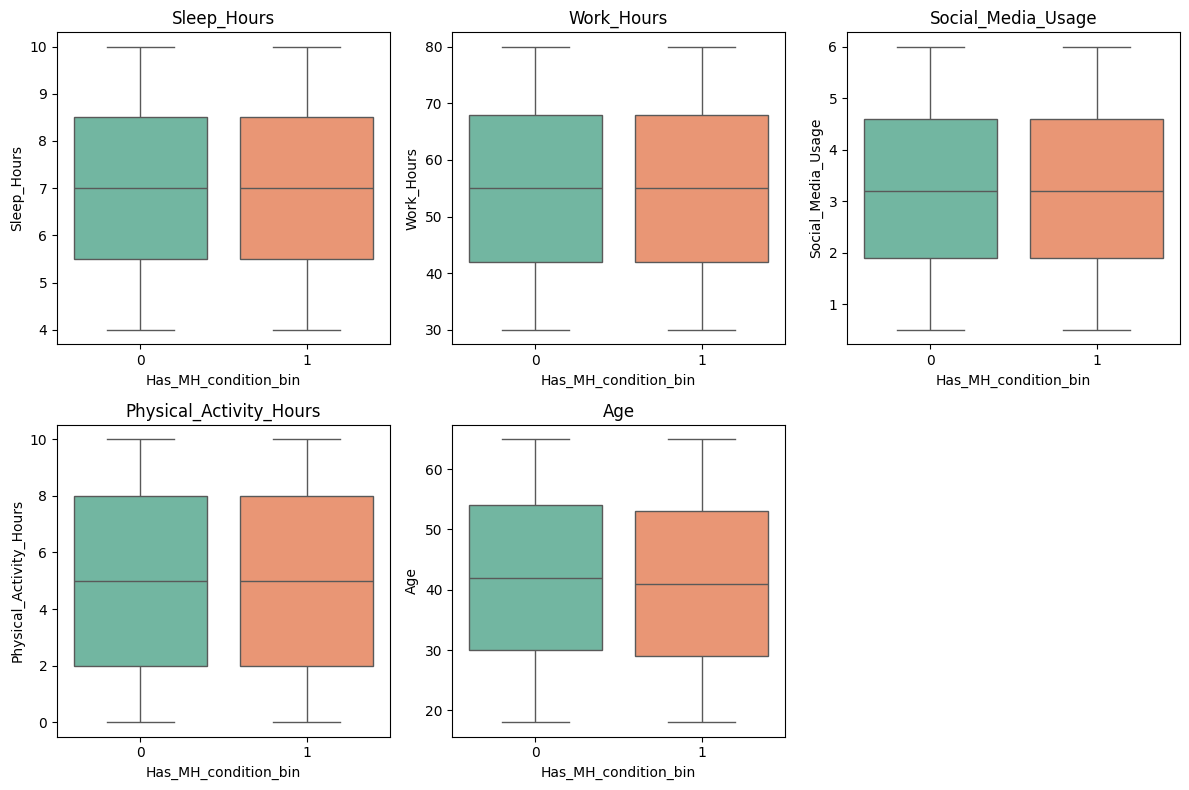

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

# --------------------------
# 1) Load dataset
# --------------------------
df = pd.read_csv("clean_numeric_model.csv")

target = "Has_MH_condition_bin"
features_to_check = ["Sleep_Hours", "Work_Hours", "Social_Media_Usage", 
                     "Physical_Activity_Hours", "Age"]

# --------------------------
# 2) Group stats
# --------------------------
print("=== Group Mean/Std by Target ===")
stats = df.groupby(target)[features_to_check].agg(["mean","std"])
print(stats)

# --------------------------
# 3) T-tests
# --------------------------
print("\n=== T-tests (0 vs 1) ===")
for feat in features_to_check:
    group0 = df.loc[df[target]==0, feat].dropna()
    group1 = df.loc[df[target]==1, feat].dropna()
    stat, pval = ttest_ind(group0, group1, equal_var=False)
    print(f"{feat:25s} | p={pval:.4e}")

# --------------------------
# 4) Boxplots for visualization
# --------------------------
plt.figure(figsize=(12,8))
for i, feat in enumerate(features_to_check, 1):
    plt.subplot(2,3,i)
    sns.boxplot(x=target, y=feat, data=df, palette="Set2")
    plt.title(feat)
plt.tight_layout()
plt.show()


---
title: "Baseline Analysis Report: Mental Health Prediction"
author: "Your Name"
date: "`r Sys.Date()`"
output: html_document
---

# Introduction

This report evaluates baseline models for predicting mental health conditions using a cleaned numeric dataset. Logistic Regression and LightGBM were applied, along with univariate statistical analysis, to assess the predictive power of available features. The goal is to identify whether meaningful signal exists in the data and to provide recommendations for further improvement.

# Results

## Logistic Regression
- Logistic Regression achieved **ROC-AUC ≈ 0.49**, essentially equivalent to random guessing.
- Precision, recall, and F1-scores for both classes were around 0.49, confirming poor discriminative ability.

## LightGBM
- LightGBM with early stopping and limited hyperparameter search achieved **validation AUC ≈ 0.51–0.52**.
- On the test set, the model yielded **ROC-AUC ≈ 0.496**, again close to random.
- The Precision-Recall curve was also flat, with performance near baseline.
- Feature importance suggested that variables such as *Sleep_Hours*, *Social_Media_Usage*, *Age*, *Work_Hours*, and *Physical_Activity_Hours* contributed most, but without translating into predictive power.

## Univariate Analysis
- Group means and standard deviations for key variables (*Sleep_Hours*, *Work_Hours*, *Social_Media_Usage*, *Physical_Activity_Hours*, *Age*) showed **minimal differences** between the two classes.
- T-tests confirmed that none of these differences were statistically significant (all p-values >> 0.05).
- These results suggest that the dataset provides little or no signal for the binary target variable.

# Discussion

The results indicate that current features do not provide predictive power for mental health status. Both linear (Logistic Regression) and non-linear (LightGBM) models fail to outperform random guessing. The lack of significant univariate differences between classes supports the conclusion that feature–label relationships are weak or highly noisy.

Possible explanations:
- **Weak or noisy labels**: The target variable may not accurately reflect underlying mental health conditions.
- **Limited feature representation**: Current numeric variables may not capture the complexity of mental health outcomes.
- **Encoding issues**: Categorical variables (e.g., country, occupation) were only label-encoded, potentially losing useful information.

# Future Work

To improve predictive performance, the following steps are recommended:

1. **Feature Engineering**
   - Create interaction terms (e.g., `Work_Hours / Sleep_Hours`, `Social_Media_Usage * Stress_Level`).
   - Apply non-linear transformations or binning (e.g., categorize sleep into `<6`, `6–8`, `>8` hours).
   - Explore advanced encoding for categorical variables (e.g., one-hot encoding, target encoding).

2. **Data Quality Check**
   - Verify the reliability of the target variable and assess label noise.
   - Re-examine the class distribution and labeling process.

3. **Modeling**
   - Expand hyperparameter search for LightGBM/XGBoost.
   - Explore deep learning approaches with embedding layers for categorical variables, provided sufficient signal exists.

4. **Evaluation**
   - Use k-fold cross-validation to reduce the chance of dataset-split bias.
   - Consider alternative metrics (e.g., PR-AUC) if class imbalance becomes more pronounced.

# Conclusion

The current dataset and feature set do not enable reliable prediction of mental health outcomes. Both Logistic Regression and LightGBM perform at chance level, consistent with the absence of significant univariate differences. Future progress depends primarily on improved feature engineering, label quality verification, and more advanced modeling techniques.
